# Project - WiFi localization using RSSI signals

## Exploratory Data Analysis

Loading dataset

In [3]:
import kagglehub # Make sure to install kagglehub using -pip install kagglehub
# Download latest version
path = kagglehub.dataset_download("brosnanyuen/wifi-rssi-indoor-localization")

/home/niko/Desktop/ml_labs/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
import pandas as pd

# Load the raw dataset
raw_dataset = path + "/SRL_KNN_RNN_Code_Folder/SSP/UpdatedDatabase_8June2018_11MAC.csv"
df = pd.read_csv(raw_dataset, header=1)
print(df.head()) 
print(df.shape)

     X    Y  84:16:f9:9f:41:d4  b0:c7:45:b3:d0:b8  84:16:f9:9f:40:15  \
0  1.0 -0.5                -38                -50                -46   
1  1.0 -0.5                -32                -48                -46   
2  1.0 -0.5                -33                -56                -49   
3  1.0 -0.5                -32                -51                -51   
4  1.0 -0.5                -33                -49                -47   

   84:16:f9:9f:41:d3  84:16:f9:9f:53:c5  84:16:f9:9f:40:14  84:16:f9:9f:55:ed  \
0                -49                -70                -58                -66   
1                -47                -70                -60                -61   
2                -46                -74                -62                -58   
3                -46                -74                -58                -60   
4                -45                -74                -57                -60   

   b0:c7:45:b3:d0:bc  00:19:5b:06:bf:c2  84:16:f9:9f:53:c4  84:16:f9:9f:55:ec  


Looking at the data, we see two columns labeled X,Y which corresponds to a 2D spatial coordinate. This will be our target variables if we make a regression model. The rest of the columns show 11 RSSI features corresponding to 11 router accesspoints MAC adresses. These 11 features indicate the RSSI signal strength at a given X,Y coordinate. 

### Visuaualizing signal strength on X,Y data points

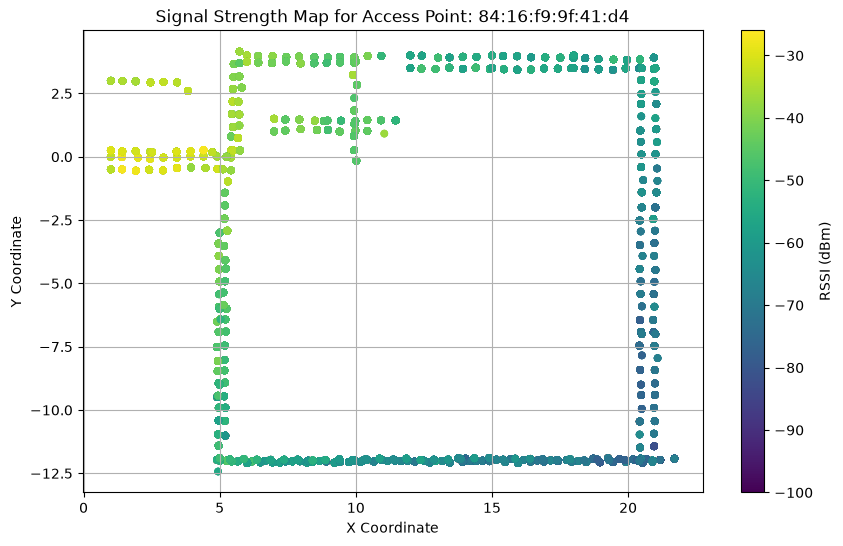

In [21]:
import matplotlib.pyplot as plt


ap_mac = df.columns[2]  # First access point

plt.figure(figsize=(10, 6))
sc = plt.scatter(df['X'], df['Y'], c=df[ap_mac], cmap='viridis', s=20)
plt.colorbar(sc, label='RSSI (dBm)')
plt.title(f"Signal Strength Map for Access Point: {ap_mac}")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)
plt.show()

This scatterplot visualizes the physical layout of the building. The first access point is located at the entrance of the floor which will act as the starting refrence of the coordinate space. The samples were taken continously and periodically from a robot on wheels using simple straight paths along the office floor. 

Signal strength is measured decibel milliwat (dBm). The closer a datapoint is to 0 dBm, the stronger the signal will be. The reason why it is measured in the dB scale is because the WiFi signals drop exponentially the further away you are, leading to very small decimal numbers which is inneficient for machine learning algorithms. Scaling the data logarithmically helps vizualize the data better and easier to compare. 

### Investigating RSSI further

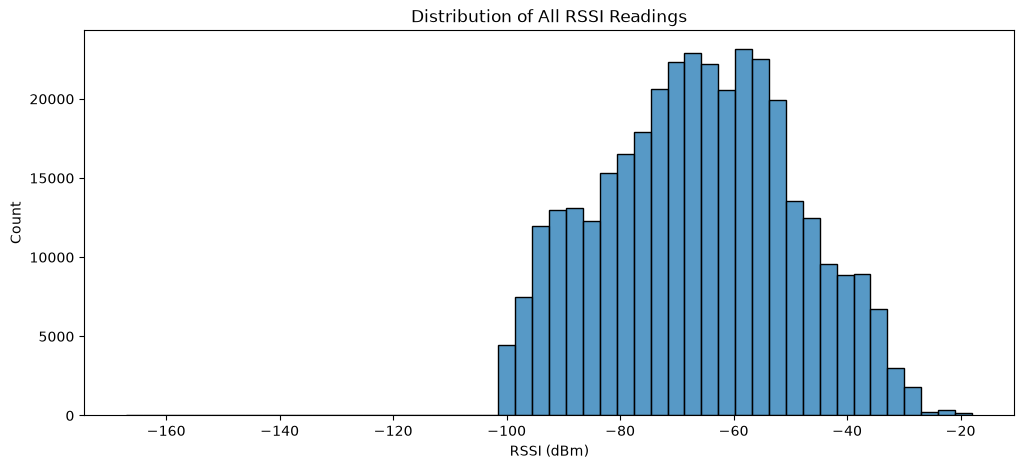

In [33]:
import seaborn as sns
# Melt dataset to plot distribution of all APs together
rssi_cols = [c for c in df.columns if c not in ['X', 'Y']]
df_melted = df[rssi_cols].melt(var_name='AP', value_name='RSSI')

plt.figure(figsize=(12, 5))
sns.histplot(data=df_melted, x='RSSI', bins=50)
plt.title("Distribution of All RSSI Readings")
plt.xlabel("RSSI (dBm)")
plt.ylabel("Count")
plt.show()

In this plot we see a histogram of different ranges in RSSI values on the X axis and their frequency in the Y axis. The majority of RSSI measurements seem to be concentrated at around -80 to -50 dBm, which indicates a moderate reception from the accesspoints. At the right tail end of the curve, we see that the strongest signals recede sharply at maximum -20 dBm. The interesting part of this histogram is at the left end of the tail where counts suddenly cuts of at around 100 dBm. This cutoff is related to the wifi chip's hardware limits as it is unable detect or distinguish signals weaker than this threshold. For that reason, we treat 100 dBm as a natural lower bound for our model. 

Another notable feature about this histogram is the possibility of signals that extend beyond -100dBm. Since the curve starts halfway through the X-axis, this may indicate that rare values exist further to the left but they are too sparse to show up visually on the graph. For that reason, we can print out the lowest RSSI values that was measured on each access point.



In [32]:
print("Minimum RSSI value per AP:")
print(df[rssi_cols].min())

Minimum RSSI value per AP:
84:16:f9:9f:41:d4   -100
b0:c7:45:b3:d0:b8   -100
84:16:f9:9f:40:15   -100
84:16:f9:9f:41:d3    -97
84:16:f9:9f:53:c5   -100
84:16:f9:9f:40:14    -97
84:16:f9:9f:55:ed   -100
b0:c7:45:b3:d0:bc   -100
00:19:5b:06:bf:c2   -100
84:16:f9:9f:53:c4   -100
84:16:f9:9f:55:ec   -167
dtype: int64


In the table above, we see an data anomaly at the last accespoint showing value of -167dBm. There might be many more values below -100 but these values impossible given the hardware that we are working with. These values may have been created artifially by the logging software used when gathering the data or generated in some other unexplainable way. For that reason, we will clip the dataset to our lower bound starting at -100dBm in order remove the unwanted noise from our dataset.